# Notebook B: Analysis, Plots & Results

**Structure:**
- **Part I (Main):** Color, Size, MMStar-Finegrained, MMStar-Coarse (n=493, 727, 231, 230)
- **Part II (Appendix):** Count and Shape added (n=3, 5) - preliminary observations only

## 0. Setup

In [1]:
import sys
!{sys.executable} -m pip install -q pandas numpy matplotlib seaborn scipy

import json, os, warnings
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 150, "savefig.bbox": "tight",
                      "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11})

OUT_MAIN = Path("./analysis_main")
OUT_APPENDIX = Path("./analysis_appendix")
OUT_MAIN.mkdir(exist_ok=True)
OUT_APPENDIX.mkdir(exist_ok=True)
print("ready")


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
ready


## 1. Load data

In [10]:
# result files
LLAVA_PATH  = Path("./results-json/llava_results.json")
QWEN2_PATH  = Path("./results-json/qwen2vl_results.json")
assert LLAVA_PATH.exists(), f"not found: {LLAVA_PATH}"
assert QWEN2_PATH.exists(), f"not found: {QWEN2_PATH}"

with open(LLAVA_PATH) as f: llava_raw = json.load(f)
with open(QWEN2_PATH) as f: qwen_raw = json.load(f)

def results_to_df(results_dict, model_name):
    rows = [v for v in results_dict.values() if "error" not in v]
    df = pd.DataFrame(rows)
    df["model"] = model_name
    df["logit_gap"] = df["final_visual_logit"] - df["final_prior_logit"]
    return df

df_llava = results_to_df(llava_raw, "LLaVA-1.5-7B")
df_qwen  = results_to_df(qwen_raw, "Qwen2-VL-7B")
df_all   = pd.concat([df_llava, df_qwen], ignore_index=True)

oom_l = sum(1 for v in llava_raw.values() if v.get("error") == "OOM")
oom_q = sum(1 for v in qwen_raw.values() if v.get("error") == "OOM")

print(f"LLaVA:    {len(df_llava)} valid ({oom_l} OOM)")
print(f"Qwen2-VL: {len(df_qwen)} valid ({oom_q} OOM)")
print(f"combined: {len(df_all)}")
print(f"attributes: {dict(Counter(df_all['attribute']))}")

# define attribute groups
MAIN_ATTRS = ["color", "size", "mmstar_finegrained", "mmstar_coarse"]
ALL_ATTRS  = ["color", "size", "mmstar_finegrained", "mmstar_coarse", "count", "shape"]
MODELS = ["LLaVA-1.5-7B", "Qwen2-VL-7B"]
COLORS_MAP = {"LLaVA-1.5-7B": "#44a4d5", "Qwen2-VL-7B": "#FFB300"}

LLaVA:    1689 valid (0 OOM)
Qwen2-VL: 1689 valid (0 OOM)
combined: 3378
attributes: {'count': 6, 'shape': 10, 'color': 986, 'size': 1454, 'mmstar_finegrained': 462, 'mmstar_coarse': 460}


## Helper functions (used by both Main and Appendix)

In [11]:
def compute_mean_trajectory(results_dict, attribute):
    trajs = [r["trajectory"] for r in results_dict.values()
             if r.get("attribute") == attribute and "error" not in r and r.get("trajectory")]
    if not trajs:
        return None, None, None, None
    max_len = max(len(t) for t in trajs)
    vm = np.full((len(trajs), max_len), np.nan)
    pm = np.full((len(trajs), max_len), np.nan)
    for i, t in enumerate(trajs):
        for j, (v, p) in enumerate(t):
            vm[i, j] = v
            pm[i, j] = p
    return np.nanmean(vm, 0), np.nanstd(vm, 0), np.nanmean(pm, 0), np.nanstd(pm, 0)


def plot_vwin_bars(attrs, title, save_path):
    present = [a for a in attrs if a in df_all["attribute"].unique()]
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(present))
    w = 0.35
    for i, model in enumerate(MODELS):
        rates = [df_all[(df_all["model"] == model) & (df_all["attribute"] == a)]["visual_wins"].mean() * 100
                 if len(df_all[(df_all["model"] == model) & (df_all["attribute"] == a)]) > 0 else 0
                 for a in present]
        bars = ax.bar(x + i*w, rates, w, label=model, color=COLORS_MAP[model], zorder=2)
        for bar, rate in zip(bars, rates):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f"{rate:.1f}%", ha="center", va="bottom", fontsize=9)
    ax.axhline(50, color="gray", ls="--", lw=1, alpha=0.5, label="chance (50%)")
    ax.set_xticks(x + w/2)
    ax.set_xticklabels(present, fontsize=10)
    ax.set_ylabel("Visual-win rate (%)")
    ax.set_title(title)
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3, zorder=1)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()


def plot_mac_depth(attrs, title, save_path):
    present = [a for a in attrs if a in df_all["attribute"].unique()]
    df_mac = df_all[df_all["attribute"].isin(present)].dropna(subset=["mac_depth_pct"])
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    for i, model in enumerate(MODELS):
        sub = df_mac[df_mac["model"] == model]
        with_data = [a for a in present if a in sub["attribute"].values]
        data = [sub[sub["attribute"] == a]["mac_depth_pct"].values for a in with_data]
        bp = axes[i].boxplot(data, labels=with_data, patch_artist=True, widths=0.6)
        for patch in bp["boxes"]:
            patch.set_facecolor(COLORS_MAP[model])
            patch.set_alpha(0.6)
        for j, d in enumerate(data):
            if len(d) > 0:
                med = np.median(d)
                axes[i].text(j+1, med+1.5, f"{med:.0f}%", ha="center", fontsize=8, color=COLORS_MAP[model])
        axes[i].set_title(model)
        axes[i].set_ylabel("MAC depth (% of total layers)" if i == 0 else "")
        axes[i].set_xlabel("attribute")
        axes[i].grid(axis="y", alpha=0.3)
    plt.suptitle(title, fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()


def plot_trajectories(attrs, results_dicts, title_prefix, save_dir):
    present = [a for a in attrs if a in df_all["attribute"].unique()]
    for model_name, rd in results_dicts:
        fig, axes = plt.subplots(1, len(present), figsize=(4.5 * len(present), 4))
        if len(present) == 1:
            axes = [axes]
        for j, attr in enumerate(present):
            vm, vs, pm, ps = compute_mean_trajectory(rd, attr)
            if vm is None:
                axes[j].set_title(f"{attr} (no data)")
                continue
            layers = np.arange(len(vm))
            axes[j].plot(layers, vm, color="#44a4d5", lw=2, label="visual")
            axes[j].fill_between(layers, vm-vs, vm+vs, color="#44a4d5", alpha=0.15)
            axes[j].plot(layers, pm, color="#FFB300", lw=2, label="prior")
            axes[j].fill_between(layers, pm-ps, pm+ps, color="#FFB300", alpha=0.15)
            macs = [r["mac_layer"] for r in rd.values() if r.get("attribute") == attr and r.get("mac_layer") is not None]
            if macs:
                axes[j].axvline(np.mean(macs), color="green", ls="--", lw=1.5, label=f"mean MAC (L{np.mean(macs):.0f})")
            vwins = [r["visual_wins"] for r in rd.values() if r.get("attribute") == attr and "error" not in r]
            vp = np.mean(vwins)*100 if vwins else 0
            axes[j].set_title(f"{attr} (V wins: {vp:.0f}%)")
            axes[j].set_xlabel("layer")
            if j == 0:
                axes[j].set_ylabel("logit value")
            axes[j].legend(fontsize=7, loc="upper left")
            axes[j].grid(alpha=0.3)
        safe = model_name.replace(".", "").replace("-", "_").replace(" ", "_")
        plt.suptitle(f"{title_prefix} - {model_name}", fontsize=12, y=1.03)
        plt.tight_layout()
        plt.savefig(save_dir / f"trajectories_{safe}.png")
        plt.show()


def build_summary_table(attrs, save_path):
    present = [a for a in attrs if a in df_all["attribute"].unique()]
    rows = []
    for model in MODELS:
        n_layers_model = 32 if "LLaVA" in model else 28
        for attr in present:
            sub = df_all[(df_all["model"] == model) & (df_all["attribute"] == attr)]
            if len(sub) == 0:
                continue
            mac_vals = sub["mac_layer"].dropna()
            rows.append({
                "Model": model, "Attribute": attr, "N": len(sub),
                "V-win%": round(sub["visual_wins"].mean() * 100, 1),
                "Mean MAC": round(mac_vals.mean(), 1) if len(mac_vals) > 0 else None,
                "MAC depth%": round(mac_vals.mean() / n_layers_model * 100, 1) if len(mac_vals) > 0 else None,
                "Mean logit gap": round(sub["logit_gap"].mean(), 2),
                "L2@25%": round(sub["l2_25"].dropna().mean(), 2) if sub["l2_25"].notna().sum() > 0 else None,
                "L2@50%": round(sub["l2_50"].dropna().mean(), 2) if sub["l2_50"].notna().sum() > 0 else None,
                "L2@75%": round(sub["l2_75"].dropna().mean(), 2) if sub["l2_75"].notna().sum() > 0 else None,
            })
    sdf = pd.DataFrame(rows)
    sdf.to_csv(save_path, index=False)
    return sdf

print("helper functions defined")

helper functions defined


---
# PART I: Main Results

**Attributes: Color (493), Size (727), MMStar-Finegrained (231), MMStar-Coarse (230)**

These are the four high-volume attributes reported in the main body of the writeup.

## 2. Visual-win rate (main attributes)

In [12]:
# ── visual-win rate table (main only) ─────────────────────────
vwin = df_all[df_all["attribute"].isin(MAIN_ATTRS)].groupby(["model", "attribute"]).agg(
    n=("visual_wins", "count"),
    vwin_pct=("visual_wins", lambda x: round(x.mean() * 100, 1)),
).reset_index()
print("Visual-win rates (main attributes):")
print(vwin.to_string(index=False))
vwin.to_csv(OUT_MAIN / "visual_win_rates_main.csv", index=False)

Visual-win rates (main attributes):
       model          attribute   n  vwin_pct
LLaVA-1.5-7B              color 493      91.5
LLaVA-1.5-7B      mmstar_coarse 230      71.3
LLaVA-1.5-7B mmstar_finegrained 231      70.6
LLaVA-1.5-7B               size 727      49.2
 Qwen2-VL-7B              color 493      82.4
 Qwen2-VL-7B      mmstar_coarse 230      73.5
 Qwen2-VL-7B mmstar_finegrained 231      75.8
 Qwen2-VL-7B               size 727      56.3


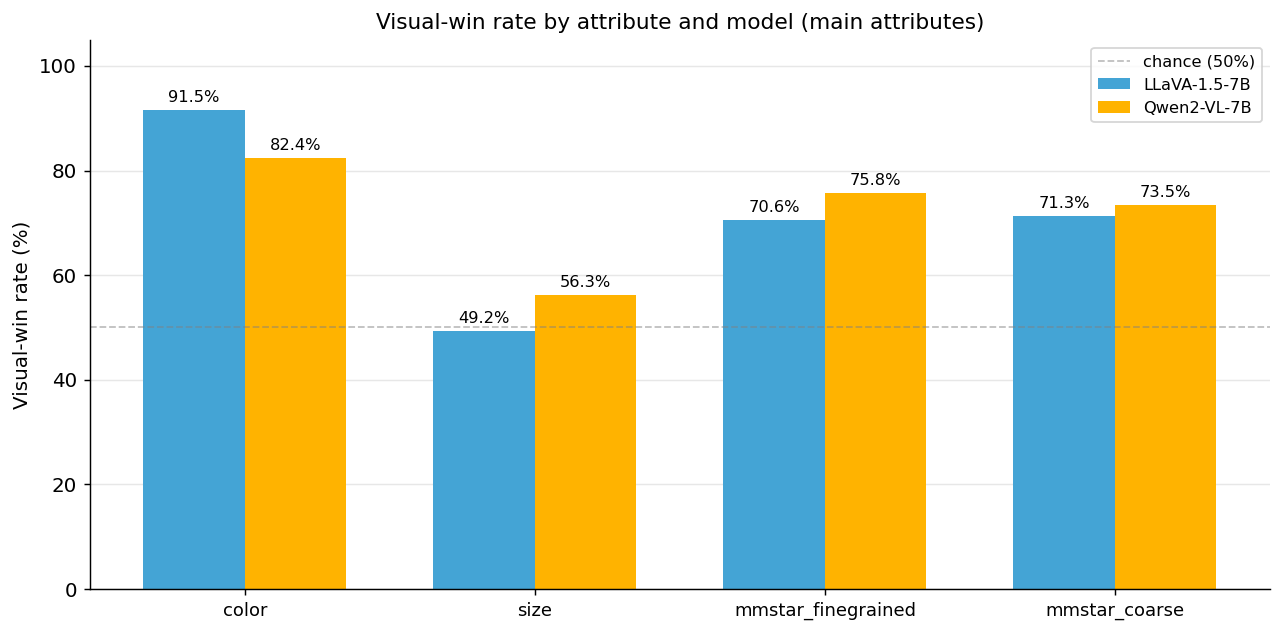

In [13]:
plot_vwin_bars(MAIN_ATTRS,
    "Visual-win rate by attribute and model (main attributes)",
    OUT_MAIN / "visual_win_rates_main.png")

## 3. MAC depth distribution (main attributes)

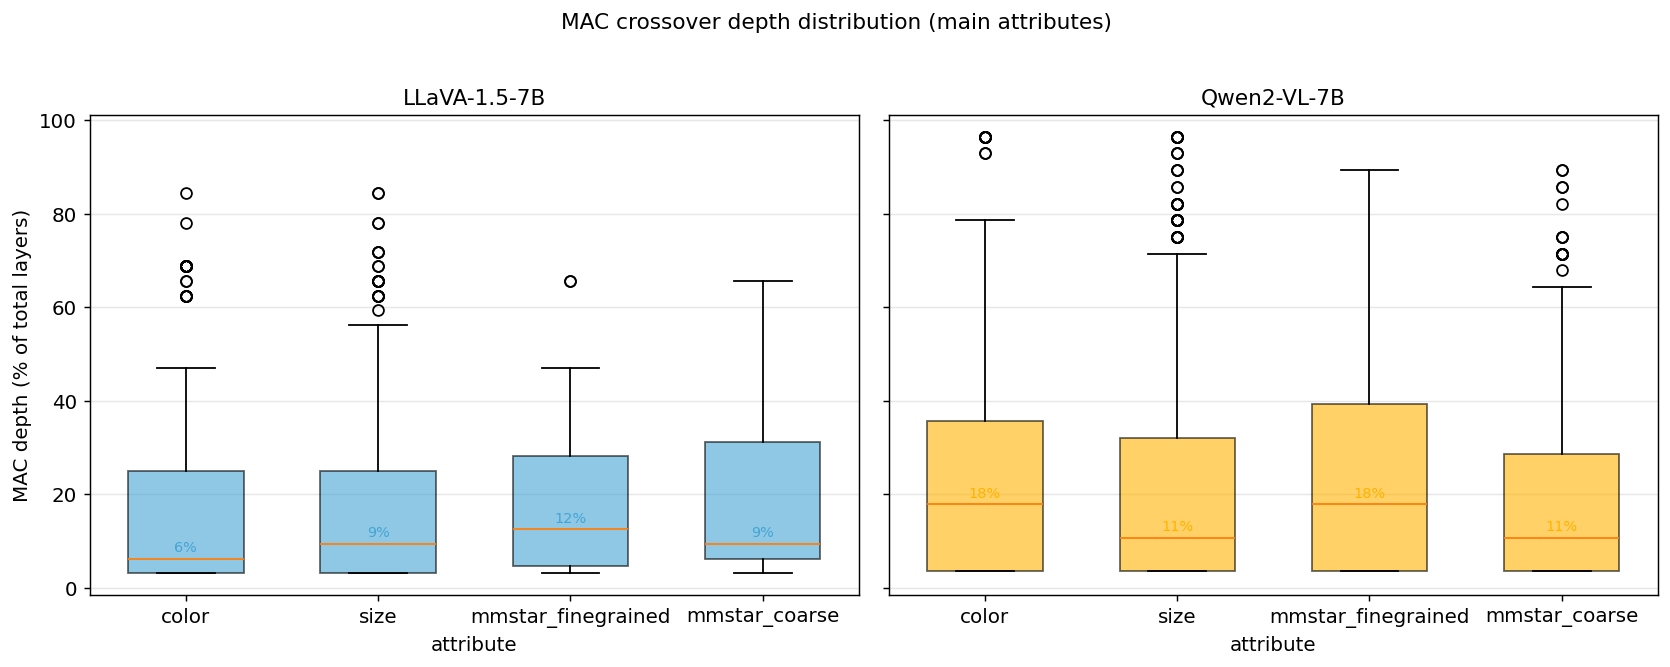

In [14]:
plot_mac_depth(MAIN_ATTRS,
    "MAC crossover depth distribution (main attributes)",
    OUT_MAIN / "mac_depth_main.png")

## 4. Mean logit trajectories (main attributes)

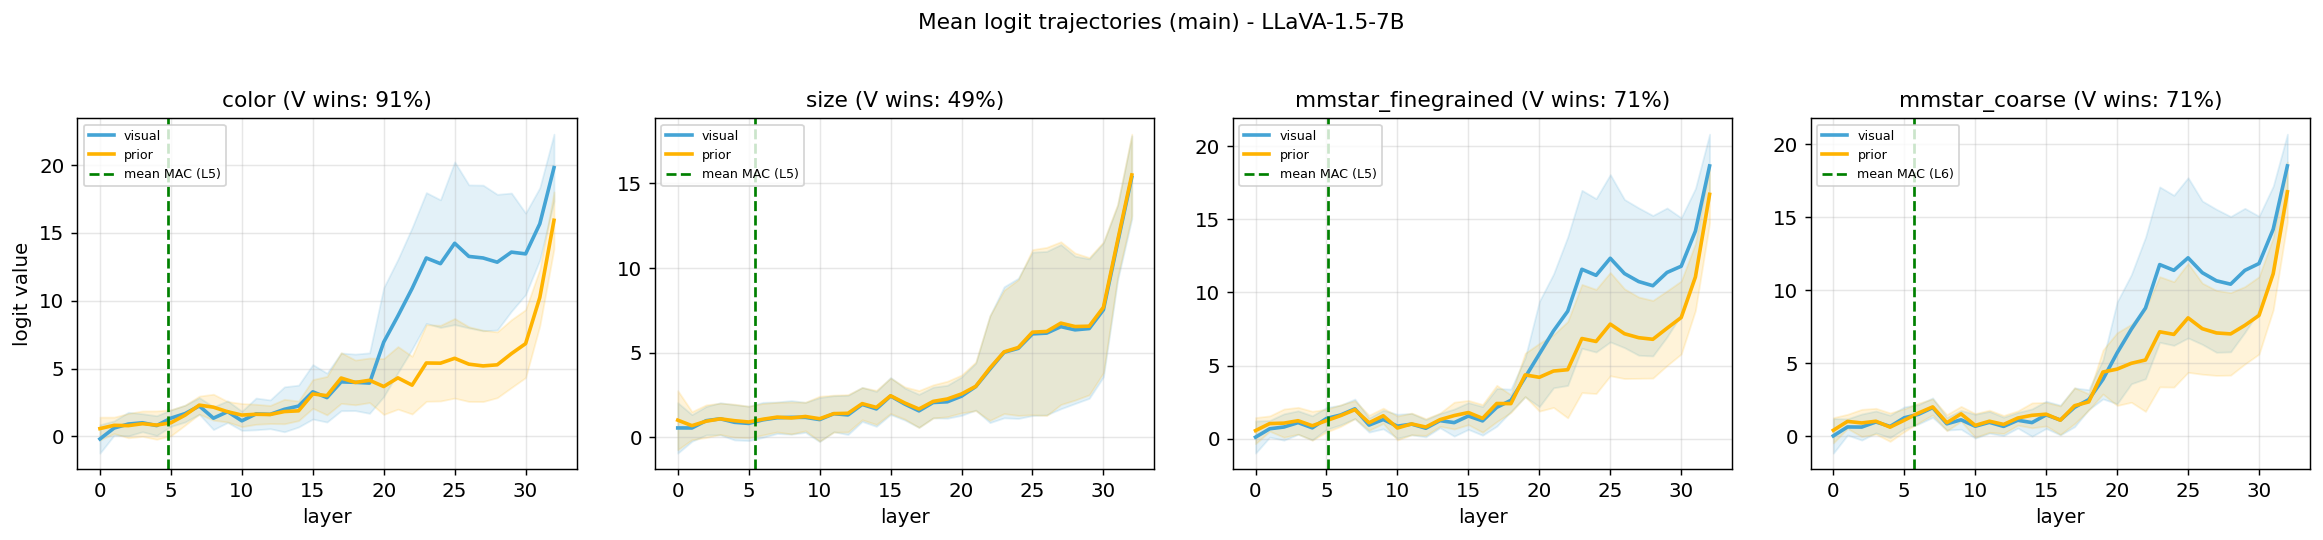

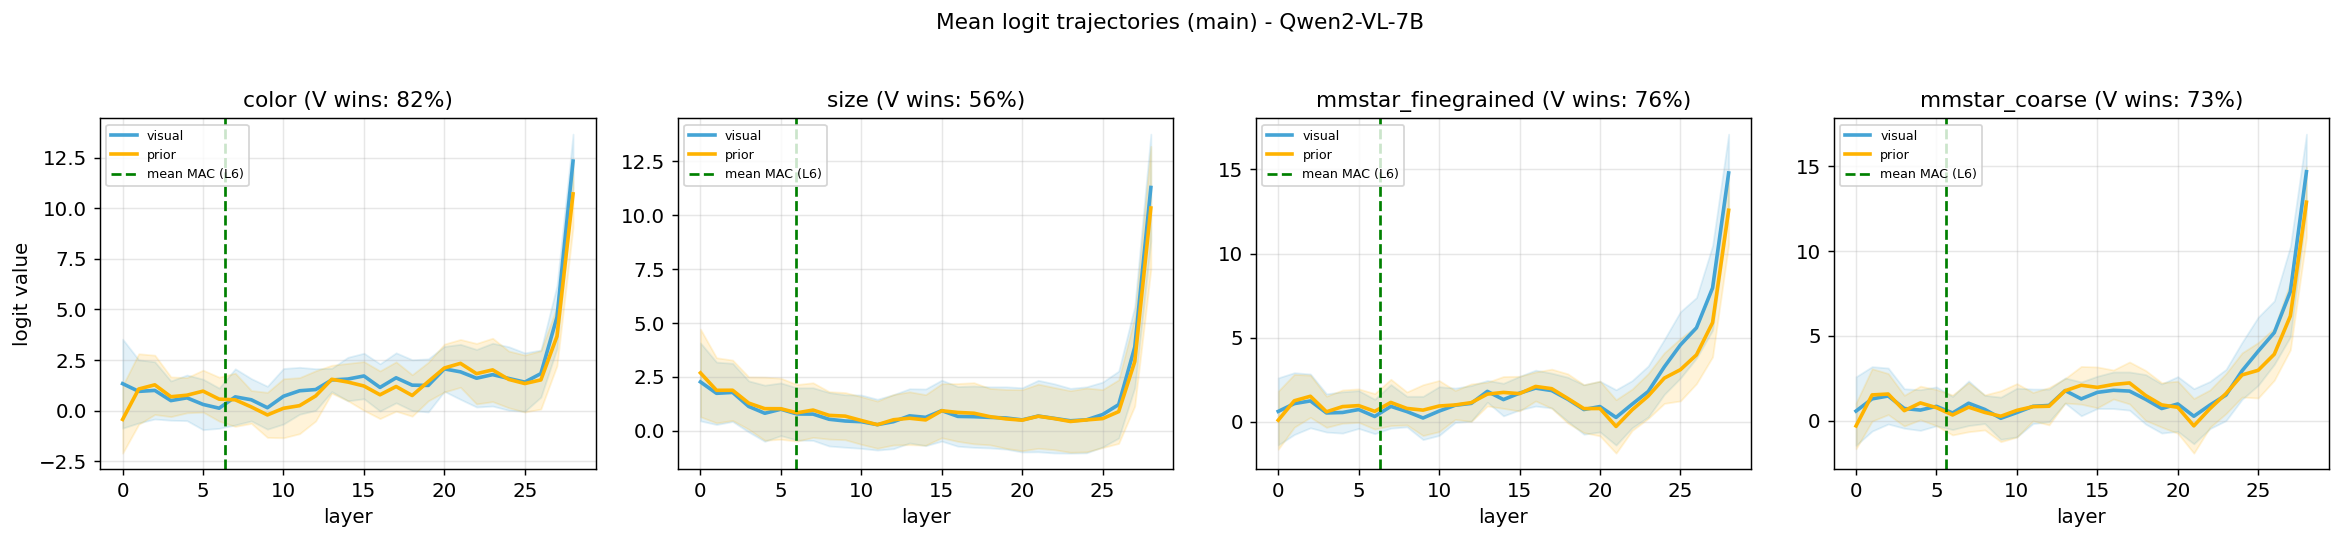

In [15]:
plot_trajectories(
    MAIN_ATTRS,
    [("LLaVA-1.5-7B", llava_raw), ("Qwen2-VL-7B", qwen_raw)],
    "Mean logit trajectories (main)",
    OUT_MAIN)

## 5. Encoding-Grounding Dissociation (main attributes)

### 5a. L2 distance: VISUAL-wins vs PRIOR-wins

In [ ]:
# dissociation on main attributes only
df_main = df_all[df_all["attribute"].isin(MAIN_ATTRS)]
dissoc_rows = []
for model in MODELS:
    sub = df_main[(df_main["model"] == model) & df_main["l2_75"].notna()]
    vg = sub[sub["visual_wins"] == True]["l2_75"]
    pg = sub[sub["visual_wins"] == False]["l2_75"]
    vm = vg.mean() if len(vg) > 0 else np.nan
    pm = pg.mean() if len(pg) > 0 else np.nan
    ratio = vm / pm if pm > 0 else np.nan
    if len(vg) > 1 and len(pg) > 1:
        stat, pval = stats.mannwhitneyu(vg, pg, alternative="two-sided")
    else:
        stat, pval = np.nan, np.nan
    dissoc_rows.append({"model": model, "VISUAL_mean_L2": round(vm, 3), "VISUAL_n": len(vg),
                        "PRIOR_mean_L2": round(pm, 3), "PRIOR_n": len(pg),
                        "ratio": round(ratio, 3), "MW_p": round(pval, 4) if not np.isnan(pval) else np.nan})

dissoc_df = pd.DataFrame(dissoc_rows)
print("Encoding-Grounding Dissociation (main attributes, L2 @ 75% MAC depth)")
print("=" * 75)
print(dissoc_df.to_string(index=False))
print()
print("ratio near 1.0 = encoding equally strong for success and failure cases")
dissoc_df.to_csv(OUT_MAIN / "dissociation_main.csv", index=False)

Encoding-Grounding Dissociation (main attributes, L2 @ 75% MAC depth)
       model  VISUAL_mean_L2  VISUAL_n  PRIOR_mean_L2  PRIOR_n  ratio   MW_p
LLaVA-1.5-7B           0.750      1136          1.567      545  0.479 0.0239
 Qwen2-VL-7B           3.406      1159          3.777      522  0.902 0.0000

ratio near 1.0 = encoding equally strong for success and failure cases


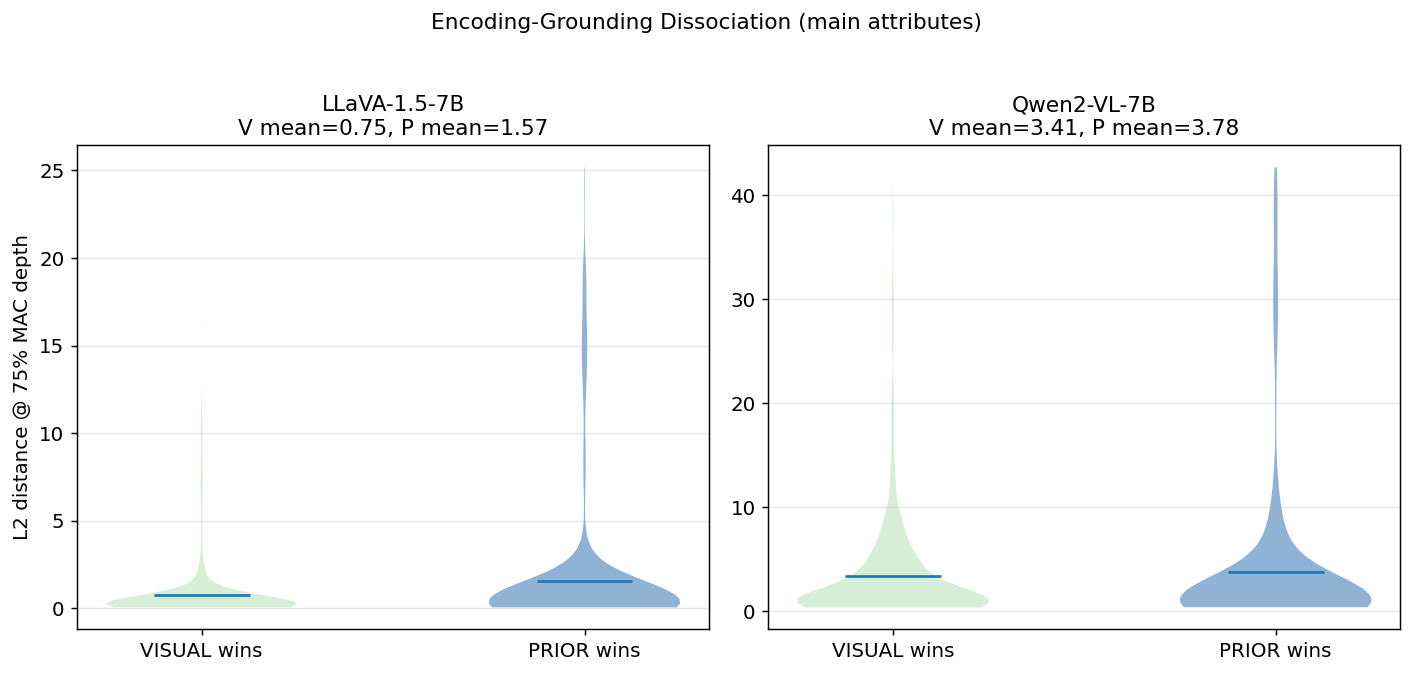

In [ ]:
# violin plot (main attributes)
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for i, model in enumerate(MODELS):
    sub = df_main[(df_main["model"] == model) & df_main["l2_75"].notna()]
    vg = sub[sub["visual_wins"] == True]["l2_75"].values
    pg = sub[sub["visual_wins"] == False]["l2_75"].values
    if len(vg) > 0 and len(pg) > 0:
        parts = axes[i].violinplot([vg, pg], positions=[0, 1], showmeans=True, showextrema=False)
        for pc, color in zip(parts["bodies"], ["#AFE1AF", "#2166AC"]):
            pc.set_facecolor(color); pc.set_alpha(0.5)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["VISUAL wins", "PRIOR wins"])
    axes[i].set_title(f"{model}\nV mean={vg.mean():.2f}, P mean={pg.mean():.2f}" if len(vg)>0 and len(pg)>0 else model)
    axes[i].set_ylabel("L2 distance @ 75% MAC depth" if i == 0 else "")
    axes[i].grid(axis="y", alpha=0.3)
plt.suptitle("Encoding-Grounding Dissociation (main attributes)", fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig(OUT_MAIN / "dissociation_violin_main.png")
plt.show()

### 5b. L2 per attribute

In [20]:
l2_main = df_main.groupby(["model", "attribute"]).agg(
    n=("l2_75", "count"),
    l2_25=("l2_25", "mean"), l2_50=("l2_50", "mean"), l2_75=("l2_75", "mean"),
).round(3)
print("L2 distances (main attributes)")
print(l2_main.to_string())
l2_main.to_csv(OUT_MAIN / "l2_per_attribute_main.csv")

L2 distances (main attributes)
                                   n  l2_25  l2_50  l2_75
model        attribute                                   
LLaVA-1.5-7B color               493  0.169  0.384  0.851
             mmstar_coarse       230  0.142  0.301  0.594
             mmstar_finegrained  231  0.119  0.255  0.379
             size                727  0.227  0.701  1.462
Qwen2-VL-7B  color               493  1.228  2.569  4.364
             mmstar_coarse       230  0.779  1.206  1.798
             mmstar_finegrained  231  0.720  1.283  1.838
             size                727  1.012  1.868  4.030


### 5c. Correlation analysis (main attributes)

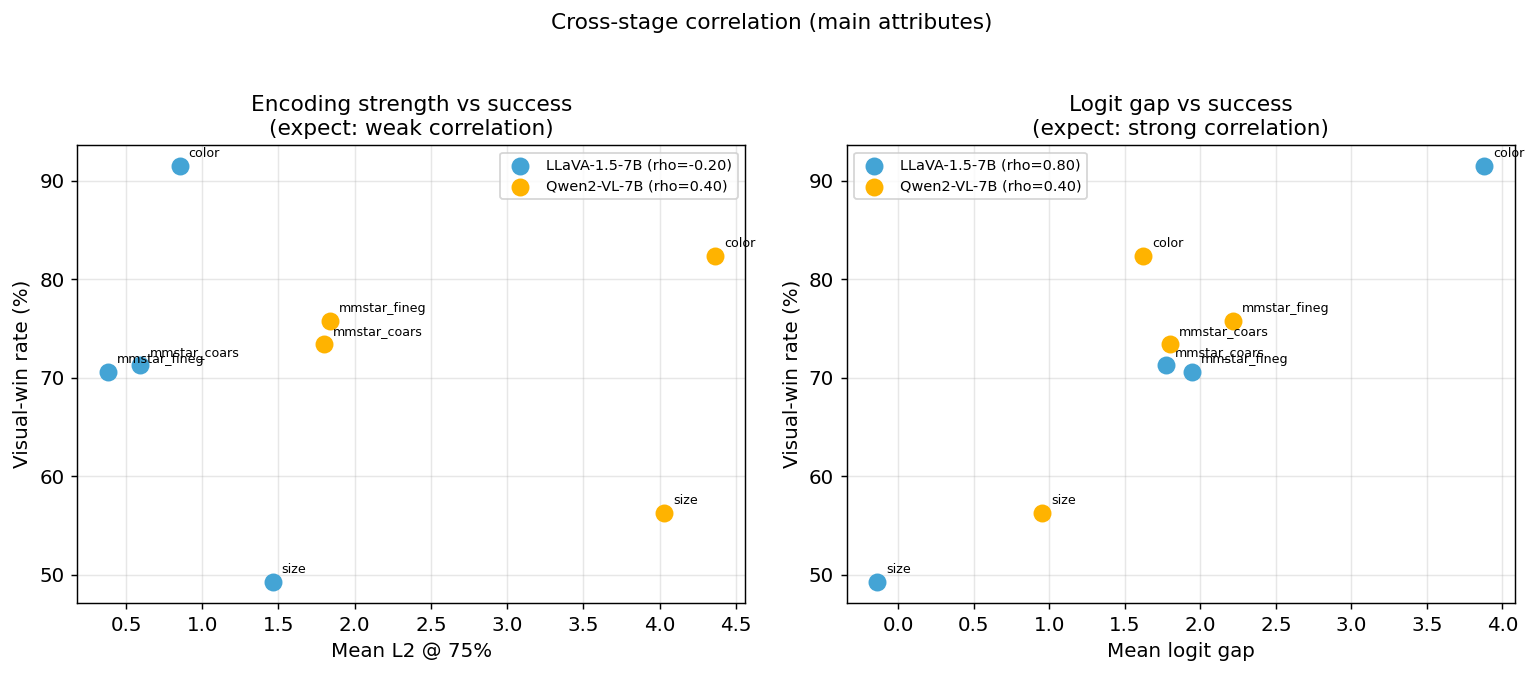

In [ ]:
# per-attribute correlation scatter
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, model in enumerate(MODELS):
    sub = df_main[(df_main["model"] == model) & df_main["l2_75"].notna()]
    attr_stats = sub.groupby("attribute").agg(
        vwin_rate=("visual_wins", "mean"), mean_l2=("l2_75", "mean"),
        mean_gap=("logit_gap", "mean"), n=("visual_wins", "count"),
    ).reset_index()
    attr_stats = attr_stats[attr_stats["n"] >= 3]
    if len(attr_stats) >= 3:
        rho_l2, p_l2 = stats.spearmanr(attr_stats["mean_l2"], attr_stats["vwin_rate"])
        axes[0].scatter(attr_stats["mean_l2"], attr_stats["vwin_rate"]*100,
                       color=COLORS_MAP[model], s=80, zorder=3, label=f"{model} (rho={rho_l2:.2f})")
        for _, row in attr_stats.iterrows():
            axes[0].annotate(row["attribute"][:12], (row["mean_l2"], row["vwin_rate"]*100),
                           fontsize=7, textcoords="offset points", xytext=(5, 5))
        rho_gap, p_gap = stats.spearmanr(attr_stats["mean_gap"], attr_stats["vwin_rate"])
        axes[1].scatter(attr_stats["mean_gap"], attr_stats["vwin_rate"]*100,
                       color=COLORS_MAP[model], s=80, zorder=3, label=f"{model} (rho={rho_gap:.2f})")
        for _, row in attr_stats.iterrows():
            axes[1].annotate(row["attribute"][:12], (row["mean_gap"], row["vwin_rate"]*100),
                           fontsize=7, textcoords="offset points", xytext=(5, 5))

axes[0].set_xlabel("Mean L2 @ 75%"); axes[0].set_ylabel("Visual-win rate (%)")
axes[0].set_title("Encoding strength vs success\n(expect: weak correlation)"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].set_xlabel("Mean logit gap"); axes[1].set_ylabel("Visual-win rate (%)")
axes[1].set_title("Logit gap vs success\n(expect: strong correlation)"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.suptitle("Cross-stage correlation (main attributes)", fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig(OUT_MAIN / "correlation_main.png")
plt.show()

In [ ]:
#  sample-level correlations (main attributes)
print("Sample-level correlations (main attributes)")
print("=" * 65)
for model in MODELS:
    sub = df_main[(df_main["model"] == model) & df_main["l2_75"].notna()]
    if len(sub) < 10:
        continue
    rho_l2, p_l2 = stats.spearmanr(sub["l2_75"], sub["visual_wins"].astype(int))
    rho_gap, p_gap = stats.spearmanr(sub["logit_gap"], sub["visual_wins"].astype(int))
    l2_str = "weak" if abs(rho_l2) < 0.3 else "moderate" if abs(rho_l2) < 0.6 else "strong"
    gap_str = "weak" if abs(rho_gap) < 0.3 else "moderate" if abs(rho_gap) < 0.6 else "strong"
    print(f"  {model}:")
    print(f"    L2 vs success:       rho={rho_l2:+.3f} (p={p_l2:.4f}) - {l2_str}")
    print(f"    logit_gap vs success: rho={rho_gap:+.3f} (p={p_gap:.4f}) - {gap_str}")

Sample-level correlations (main attributes)
  LLaVA-1.5-7B:
    L2 vs success:       rho=-0.055 (p=0.0239) - weak
    logit_gap vs success: rho=+0.811 (p=0.0000) - strong
  Qwen2-VL-7B:
    L2 vs success:       rho=+0.102 (p=0.0000) - weak
    logit_gap vs success: rho=+0.801 (p=0.0000) - strong


## 6. Behavioral analysis (main attributes)

Behavioral classification (main attributes)
Counts:
answer_class  visual-follow  prior-follow  both-mentioned  other
model                                                           
LLaVA-1.5-7B             71             3               6     12
Qwen2-VL-7B              74             2               5     11

Percentages:
answer_class  visual-follow  prior-follow  both-mentioned  other
model                                                           
LLaVA-1.5-7B           77.2           3.3             6.5   13.0
Qwen2-VL-7B            80.4           2.2             5.4   12.0


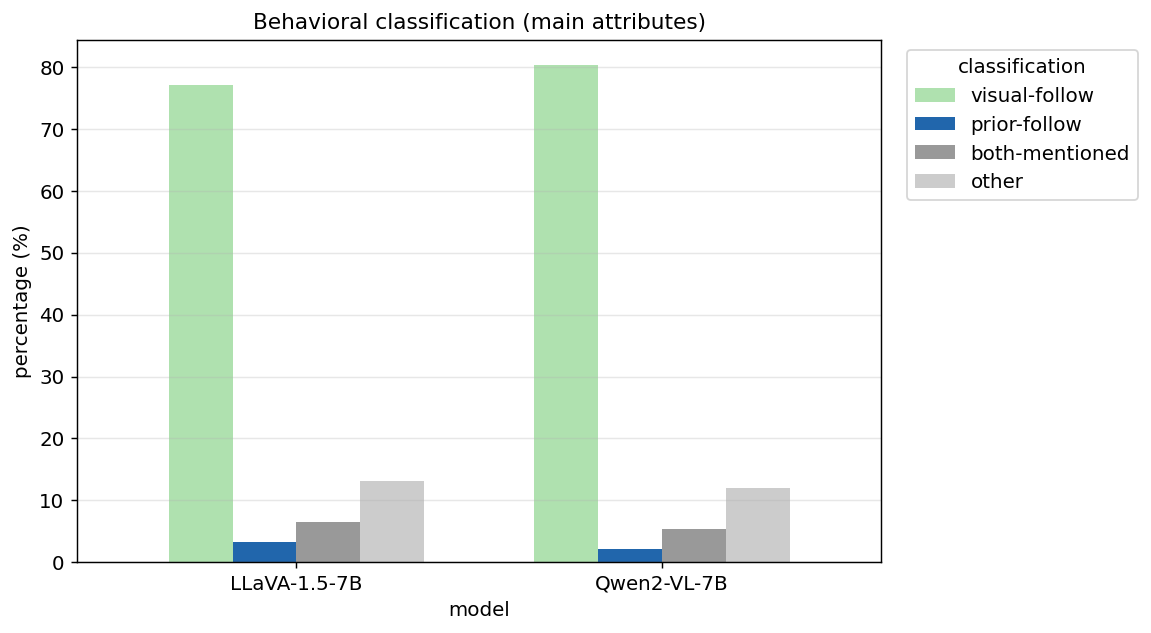

In [24]:
beh = df_main[df_main["answer_class"] != ""].copy()
if len(beh) > 0:
    beh_table = beh.groupby(["model", "answer_class"]).size().unstack(fill_value=0)
    col_order = [c for c in ["visual-follow", "prior-follow", "both-mentioned", "other"] if c in beh_table.columns]
    beh_table = beh_table[col_order]
    beh_pct = beh_table.div(beh_table.sum(axis=1), axis=0) * 100
    print("Behavioral classification (main attributes)")
    print("Counts:"); print(beh_table.to_string())
    print("\nPercentages:"); print(beh_pct.round(1).to_string())
    beh_table.to_csv(OUT_MAIN / "behavioral_main.csv")

    fig, ax = plt.subplots(figsize=(9, 5))
    beh_pct.plot.bar(ax=ax, color=["#AFE1AF", "#2166AC", "#999999", "#CCCCCC"], width=0.7)
    ax.set_ylabel("percentage (%)"); ax.set_title("Behavioral classification (main attributes)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title="classification", bbox_to_anchor=(1.02, 1), loc="upper left"); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.savefig(OUT_MAIN / "behavioral_main.png"); plt.show()

## 7. Master summary table (main attributes)

In [25]:
summary_main = build_summary_table(MAIN_ATTRS, OUT_MAIN / "master_table_main.csv")
print("=" * 90)
print("MASTER RESULTS TABLE (MAIN)")
print("=" * 90)
print(summary_main.to_string(index=False))

MASTER RESULTS TABLE (MAIN)
       Model          Attribute   N  V-win%  Mean MAC  MAC depth%  Mean logit gap  L2@25%  L2@50%  L2@75%
LLaVA-1.5-7B              color 493    91.5       4.8        15.0            3.88    0.17    0.38    0.85
LLaVA-1.5-7B               size 727    49.2       5.5        17.1           -0.14    0.23    0.70    1.46
LLaVA-1.5-7B mmstar_finegrained 231    70.6       5.1        15.9            1.95    0.12    0.26    0.38
LLaVA-1.5-7B      mmstar_coarse 230    71.3       5.7        17.7            1.77    0.14    0.30    0.59
 Qwen2-VL-7B              color 493    82.4       6.4        22.7            1.62    1.23    2.57    4.36
 Qwen2-VL-7B               size 727    56.3       5.9        21.2            0.95    1.01    1.87    4.03
 Qwen2-VL-7B mmstar_finegrained 231    75.8       6.3        22.6            2.22    0.72    1.28    1.84
 Qwen2-VL-7B      mmstar_coarse 230    73.5       5.6        19.9            1.80    0.78    1.21    1.80


## 8. Key findings (main attributes)

In [26]:
print("=" * 60)
print("KEY FINDINGS (MAIN ATTRIBUTES)")
print("=" * 60)

llava_color = df_main[(df_main["model"] == "LLaVA-1.5-7B") & (df_main["attribute"] == "color")]["visual_wins"].mean() * 100
qwen_color = df_main[(df_main["model"] == "Qwen2-VL-7B") & (df_main["attribute"] == "color")]["visual_wins"].mean() * 100
llava_size = df_main[(df_main["model"] == "LLaVA-1.5-7B") & (df_main["attribute"] == "size")]["visual_wins"].mean() * 100

repl = "REPLICATES" if abs(llava_color - 91) < 5 else "DIFFERS"
print(f"\n1. REPLICATION: LLaVA Color = {llava_color:.1f}% (paper: 91%) - {repl}")

print(f"\n2. CROSS-MODEL: LLaVA {llava_color:.1f}% vs Qwen2-VL {qwen_color:.1f}% ({llava_color - qwen_color:+.1f} pp)")

print("\n3. DISSOCIATION:")
for model in MODELS:
    sub = df_main[(df_main["model"] == model) & df_main["l2_75"].notna()]
    if len(sub) < 10:
        continue
    rho_l2, p_l2 = stats.spearmanr(sub["l2_75"], sub["visual_wins"].astype(int))
    rho_gap, p_gap = stats.spearmanr(sub["logit_gap"], sub["visual_wins"].astype(int))
    print(f"   {model}: L2 rho={rho_l2:+.3f} | gap rho={rho_gap:+.3f}")

print("\n4. MMSTAR EXTENSION:")
for mm in ["mmstar_finegrained", "mmstar_coarse"]:
    lv = df_all[(df_all["model"] == "LLaVA-1.5-7B") & (df_all["attribute"] == mm)]["visual_wins"].mean() * 100
    qv = df_all[(df_all["model"] == "Qwen2-VL-7B") & (df_all["attribute"] == mm)]["visual_wins"].mean() * 100
    print(f"   {mm}: LLaVA {lv:.1f}%, Qwen2-VL {qv:.1f}% (vs Color: {llava_color:.1f}%/{qwen_color:.1f}%)")

llava_fg = df_all[(df_all["model"] == "LLaVA-1.5-7B") & (df_all["attribute"] == "mmstar_finegrained")]["visual_wins"].mean() * 100
llava_co = df_all[(df_all["model"] == "LLaVA-1.5-7B") & (df_all["attribute"] == "mmstar_coarse")]["visual_wins"].mean() * 100
print(f"   FG vs Coarse gap (LLaVA): {abs(llava_fg - llava_co):.1f} pp")

print(f"\n5. ATTRIBUTE-SPECIFIC: Color({llava_color:.1f}%) vs Size({llava_size:.1f}%) = {abs(llava_color-llava_size):.1f} pp gap")

print("\n" + "=" * 60)

KEY FINDINGS (MAIN ATTRIBUTES)

1. REPLICATION: LLaVA Color = 91.5% (paper: 91%) - REPLICATES

2. CROSS-MODEL: LLaVA 91.5% vs Qwen2-VL 82.4% (+9.1 pp)

3. DISSOCIATION:
   LLaVA-1.5-7B: L2 rho=-0.055 | gap rho=+0.811
   Qwen2-VL-7B: L2 rho=+0.102 | gap rho=+0.801

4. MMSTAR EXTENSION:
   mmstar_finegrained: LLaVA 70.6%, Qwen2-VL 75.8% (vs Color: 91.5%/82.4%)
   mmstar_coarse: LLaVA 71.3%, Qwen2-VL 73.5% (vs Color: 91.5%/82.4%)
   FG vs Coarse gap (LLaVA): 0.7 pp

5. ATTRIBUTE-SPECIFIC: Color(91.5%) vs Size(49.2%) = 42.2 pp gap



---
# PART II: Appendix (all 6 attributes including Count & Shape)

Count (n=3) and Shape (n=5) are too small for statistical conclusions.
Included as preliminary observations only.

## A1. Visual-win rate (all attributes)

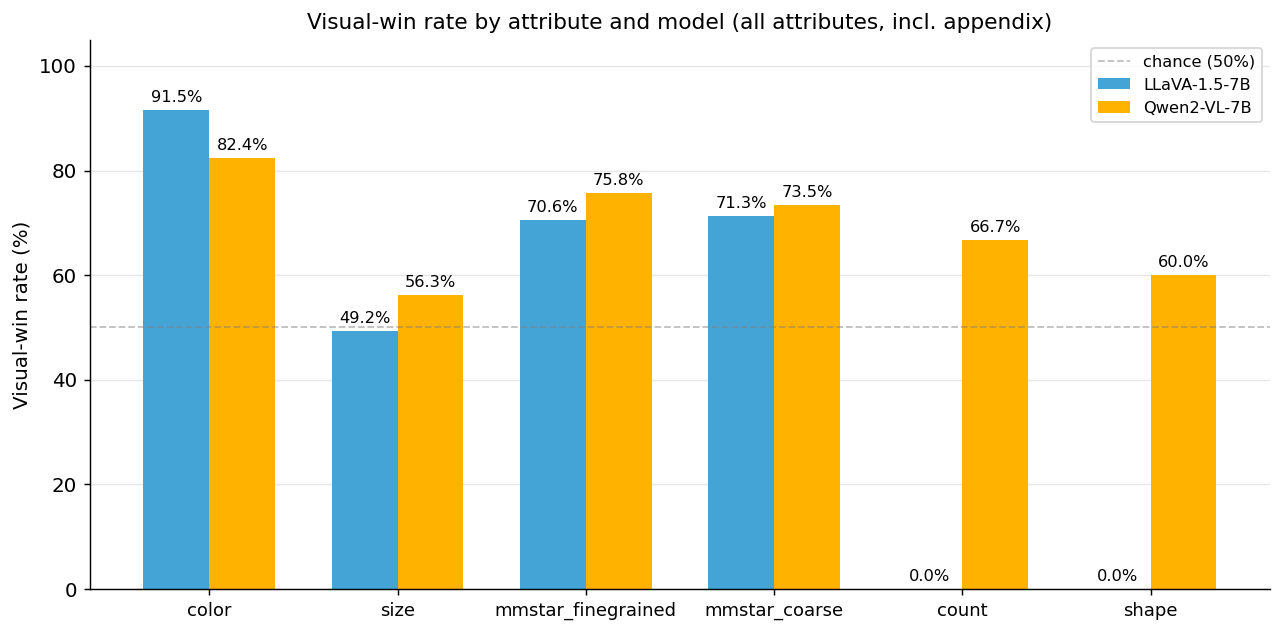

In [27]:
plot_vwin_bars(ALL_ATTRS,
    "Visual-win rate by attribute and model (all attributes, incl. appendix)",
    OUT_APPENDIX / "visual_win_rates_all.png")

## A2. MAC depth distribution (all attributes)

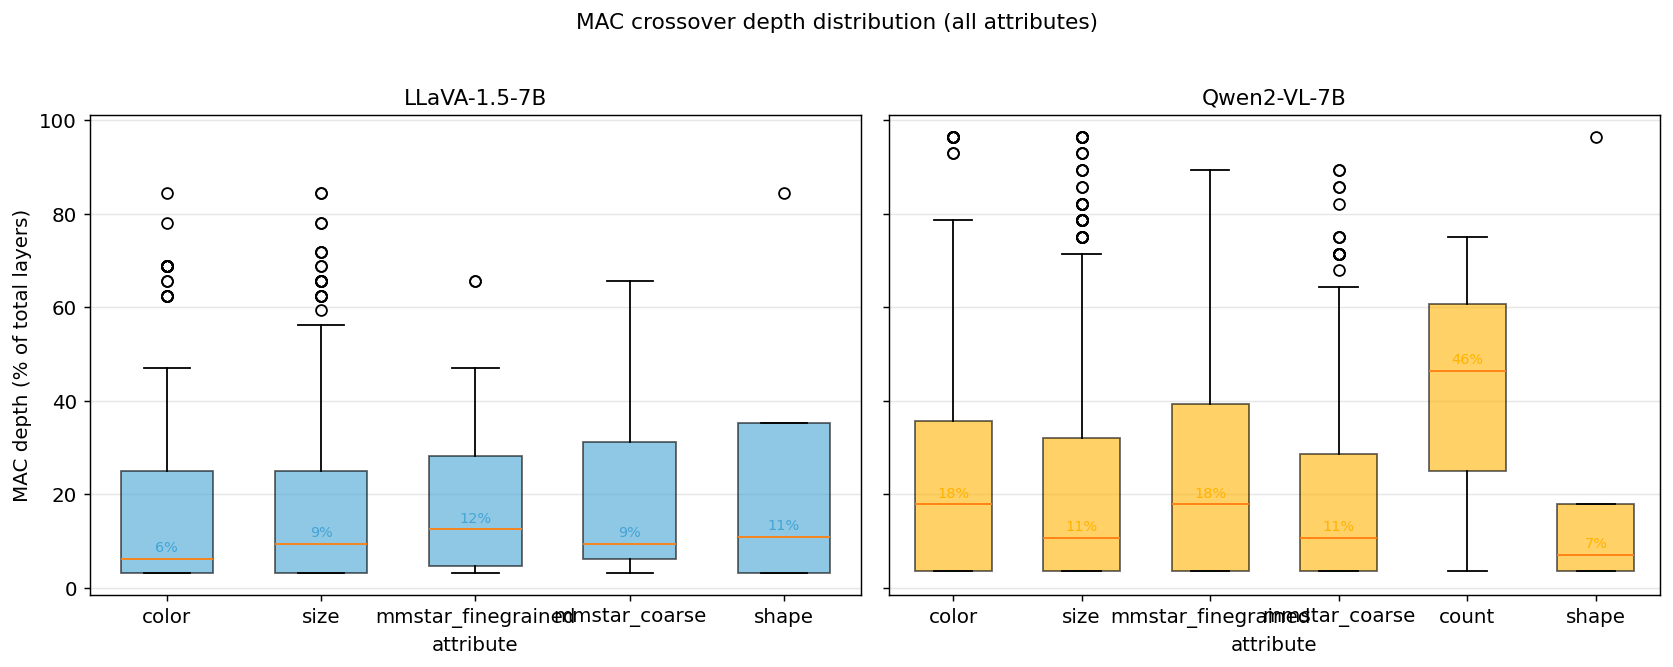

In [28]:
plot_mac_depth(ALL_ATTRS,
    "MAC crossover depth distribution (all attributes)",
    OUT_APPENDIX / "mac_depth_all.png")

## A3. Mean logit trajectories (all attributes)

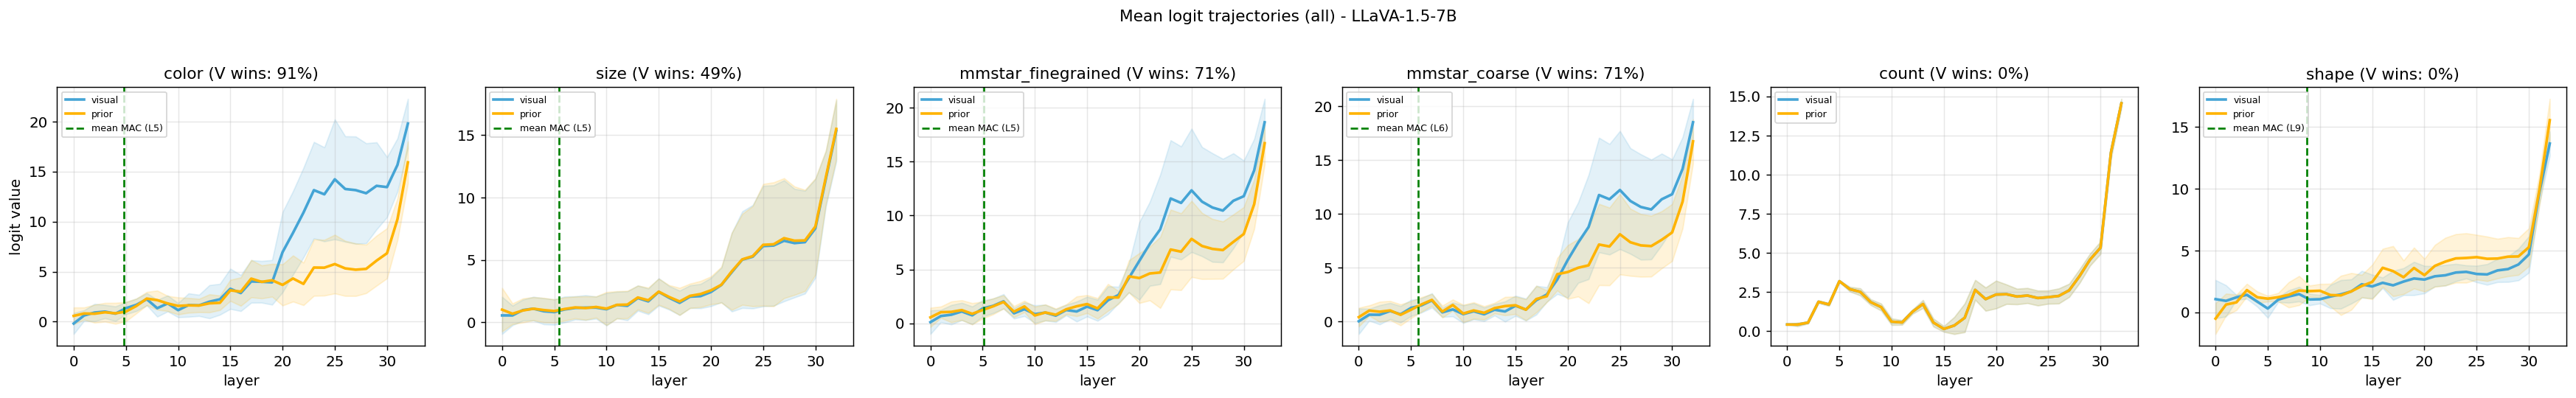

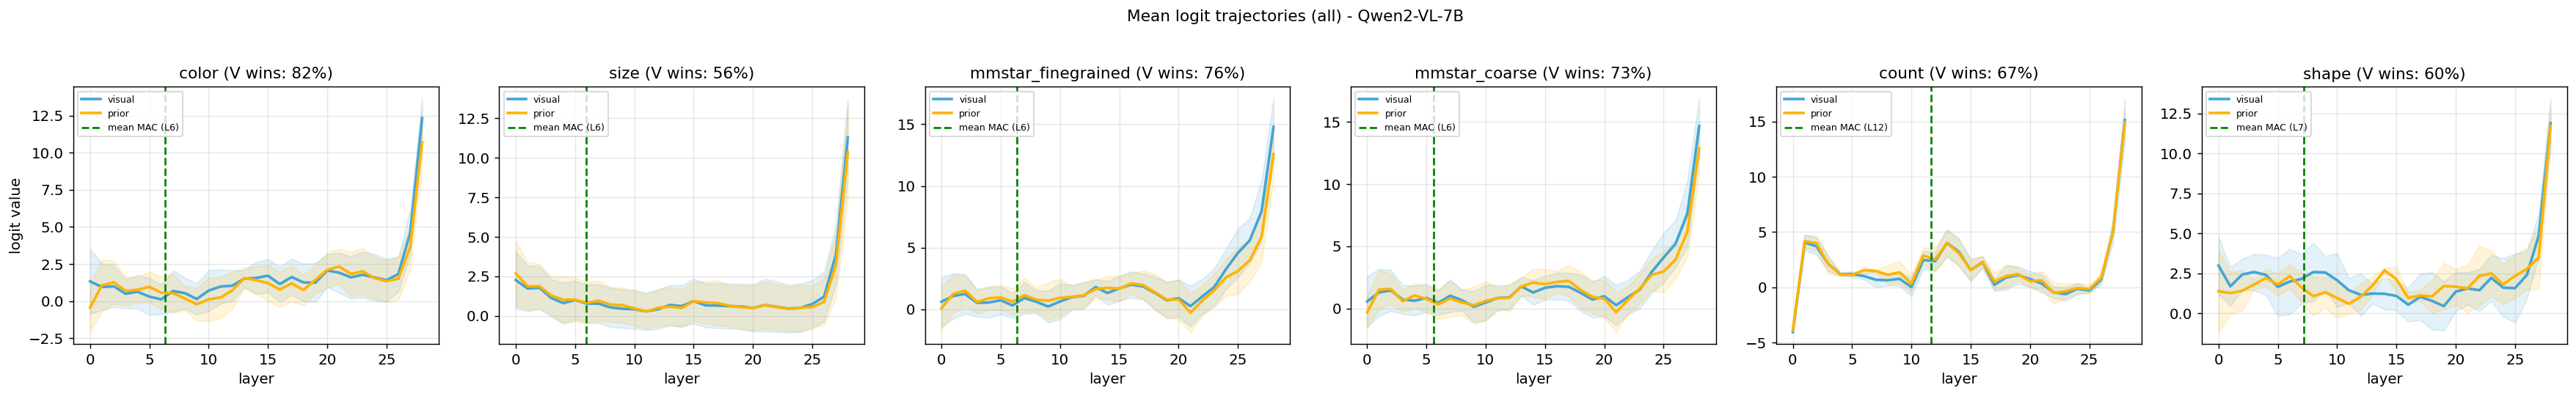

In [29]:
plot_trajectories(
    ALL_ATTRS,
    [("LLaVA-1.5-7B", llava_raw), ("Qwen2-VL-7B", qwen_raw)],
    "Mean logit trajectories (all)",
    OUT_APPENDIX)

## A4. Dissociation (all attributes)

In [30]:
dissoc_all_rows = []
for model in MODELS:
    sub = df_all[(df_all["model"] == model) & df_all["l2_75"].notna()]
    vg = sub[sub["visual_wins"] == True]["l2_75"]
    pg = sub[sub["visual_wins"] == False]["l2_75"]
    vm = vg.mean() if len(vg) > 0 else np.nan
    pm = pg.mean() if len(pg) > 0 else np.nan
    ratio = vm / pm if pm > 0 else np.nan
    if len(vg) > 1 and len(pg) > 1:
        stat, pval = stats.mannwhitneyu(vg, pg, alternative="two-sided")
    else:
        stat, pval = np.nan, np.nan
    dissoc_all_rows.append({"model": model, "V_mean": round(vm, 3), "V_n": len(vg),
                            "P_mean": round(pm, 3), "P_n": len(pg),
                            "ratio": round(ratio, 3), "MW_p": round(pval, 4) if not np.isnan(pval) else np.nan})

print("Dissociation (ALL attributes incl. count/shape)")
print(pd.DataFrame(dissoc_all_rows).to_string(index=False))

Dissociation (ALL attributes incl. count/shape)
       model  V_mean  V_n  P_mean  P_n  ratio   MW_p
LLaVA-1.5-7B   0.750 1136   1.706  553  0.440 0.0105
 Qwen2-VL-7B   3.427 1164   3.776  525  0.908 0.0000


## A5. Master summary table (all attributes)

In [31]:
summary_all = build_summary_table(ALL_ATTRS, OUT_APPENDIX / "master_table_all.csv")
print("MASTER RESULTS TABLE (ALL, incl. appendix)")
print("=" * 90)
print(summary_all.to_string(index=False))

MASTER RESULTS TABLE (ALL, incl. appendix)
       Model          Attribute   N  V-win%  Mean MAC  MAC depth%  Mean logit gap  L2@25%  L2@50%  L2@75%
LLaVA-1.5-7B              color 493    91.5       4.8        15.0            3.88    0.17    0.38    0.85
LLaVA-1.5-7B               size 727    49.2       5.5        17.1           -0.14    0.23    0.70    1.46
LLaVA-1.5-7B mmstar_finegrained 231    70.6       5.1        15.9            1.95    0.12    0.26    0.38
LLaVA-1.5-7B      mmstar_coarse 230    71.3       5.7        17.7            1.77    0.14    0.30    0.59
LLaVA-1.5-7B              count   3     0.0       NaN         NaN            0.00    1.54    5.55   11.93
LLaVA-1.5-7B              shape   5     0.0       8.8        27.3           -1.89    0.74    3.87   10.73
 Qwen2-VL-7B              color 493    82.4       6.4        22.7            1.62    1.23    2.57    4.36
 Qwen2-VL-7B               size 727    56.3       5.9        21.2            0.95    1.01    1.87    4.03
 Qw

## A6. Behavioral examples (prior-follow cases)

In [32]:
beh_all = df_all[df_all["answer_class"] != ""]
pf = beh_all[beh_all["answer_class"] == "prior-follow"].head(10)
if len(pf) > 0:
    print("Prior-follow examples (arbitration failure in generated text):")
    print("-" * 70)
    for _, row in pf.iterrows():
        print(f"  [{row['model']}] {row['attribute']} | {row['object']}")
        print(f"    visual={row['visual_answer']}, prior={row['prior_answer']}")
        print(f"    model said: '{row['model_answer']}'")
        print()
else:
    print("no prior-follow examples in generated answers")

Prior-follow examples (arbitration failure in generated text):
----------------------------------------------------------------------
  [LLaVA-1.5-7B] shape | orange_fruit
    visual=oval, prior=round
    model said: 'The orange fruit on the table in the kitchen is round in shape.'

  [LLaVA-1.5-7B] color | blueberry
    visual=brown, prior=blue
    model said: 'The blueberry is black.'

  [LLaVA-1.5-7B] color | bluejay
    visual=orange, prior=blue
    model said: 'The bluejay is brown and white.'

  [LLaVA-1.5-7B] color | board_(black)
    visual=pink, prior=black
    model said: 'Black'

  [Qwen2-VL-7B] shape | orange_fruit
    visual=oval, prior=round
    model said: 'The orange fruit on the table in the kitchen is round.'

  [Qwen2-VL-7B] color | blueberry
    visual=brown, prior=blue
    model said: 'The blueberry is black.'

  [Qwen2-VL-7B] color | bluejay
    visual=orange, prior=blue
    model said: 'The bird in the picture is a blue jay. It has a blue'



## A7. Per-attribute behavioral breakdown (all)

In [33]:
beh_all_table = beh_all.groupby(["model", "attribute", "answer_class"]).size().unstack(fill_value=0)
col_order = [c for c in ["visual-follow", "prior-follow", "both-mentioned", "other"] if c in beh_all_table.columns]
beh_all_table = beh_all_table[col_order]
print("Per-attribute behavioral classification (all)")
print(beh_all_table.to_string())
beh_all_table.to_csv(OUT_APPENDIX / "behavioral_all.csv")

Per-attribute behavioral classification (all)
answer_class            visual-follow  prior-follow  both-mentioned  other
model        attribute                                                    
LLaVA-1.5-7B color                 71             3               6     12
             count                  0             0               0      3
             shape                  1             1               0      3
Qwen2-VL-7B  color                 74             2               5     11
             count                  0             0               0      3
             shape                  0             1               0      4


## A8. All saved outputs

In [34]:
print("MAIN outputs:")
for f in sorted(OUT_MAIN.iterdir()):
    print(f"  {f.name}")
print(f"\nAPPENDIX outputs:")
for f in sorted(OUT_APPENDIX.iterdir()):
    print(f"  {f.name}")

MAIN outputs:
  behavioral_main.csv
  behavioral_main.png
  correlation_main.png
  dissociation_main.csv
  dissociation_violin_main.png
  l2_per_attribute_main.csv
  mac_depth_main.png
  master_table_main.csv
  trajectories_LLaVA_15_7B.png
  trajectories_Qwen2_VL_7B.png
  visual_win_rates_main.csv
  visual_win_rates_main.png

APPENDIX outputs:
  behavioral_all.csv
  mac_depth_all.png
  master_table_all.csv
  trajectories_LLaVA_15_7B.png
  trajectories_Qwen2_VL_7B.png
  visual_win_rates_all.png


In [ ]:
#DONE